# Hito 1 Baseline - F1 Race Strategy Advisor

This notebook uses the official race-level capstone file, implements the locked target (`is_top10`) and temporal split, calibrates on 2022 only, and evaluates once on the untouched 2023-2024 test block.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 414
DATA_CANDIDATES = [
    Path('data/f1_strategy_race_level.csv'),
    Path('hito1/data/f1_strategy_race_level.csv'),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
pd.set_option('display.max_columns', 120)

## 1. Load Official Race-Level Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())
required = {'season', 'is_top10', 'grid_position', 'n_stops', 'compound_sequence'}
assert required.issubset(df.columns), required - set(df.columns)

(2447, 47)


,season,round,race_name,circuit_id,circuit,circuit_type,driver_id,driver_name,Driver,Team,constructor_name,grid_position,qualifying_position,qualifying_time_s,driver_prior3_avg_finish,constructor_prior3_avg_finish,driver_circuit_prior_avg,constructor_tier,n_stops,strategy_type,compound_sequence,stint_lengths,stint1_length,stint2_length,stint3_length,stint4_length,stint5_length,avg_pit_stop_duration_s,total_pit_time_s,first_pit_lap,last_pit_lap,track_status_summary,safety_car_periods,safety_car_laps,vsc_laps,weather_actual,wet_laps,avg_track_temp,avg_air_temp,finish_position,points,positions_gained,is_top3,is_top5,is_top10,dnf,status
0,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,bottas,Bottas,BOT,Mercedes,Mercedes,2.0,2.0,NaN,10.5,10.5,10.5,midfield,1,one_stop,S-M,21-34,21,34,0,0,0,22.070,22.070,23.0,23.0,green=54;yellow=1,0,0,0,dry,0,40.300000,23.329091,1,26.0,1.0,1,1,1,0,Finished
1,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,hamilton,Hamilton,HAM,Mercedes,Mercedes,1.0,1.0,NaN,10.5,1.0,10.5,front,1,one_stop,S-M,13-42,13,42,0,0,0,21.010,21.010,15.0,15.0,green=54;yellow=1,0,0,0,dry,0,40.260000,23.330909,2,18.0,-1.0,1,1,1,0,Finished
2,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,max_verstappen,Verstappen,VER,Red Bull,Red Bull,4.0,4.0,NaN,10.5,11.0,10.5,midfield,1,one_stop,S-M,23-32,23,32,0,0,0,20.850,20.850,25.0,25.0,green=54;yellow=1,0,0,0,dry,0,40.276364,23.334545,3,15.0,1.0,1,1,1,0,Finished
3,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,vettel,Vettel,VET,Ferrari,Ferrari,3.0,3.0,NaN,10.5,5.0,10.5,front,1,one_stop,S-M,12-43,12,43,0,0,0,24.215,24.215,14.0,14.0,green=54;yellow=1,0,0,0,dry,0,40.234545,23.338182,4,12.0,-1.0,0,1,1,0,Finished
4,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,leclerc,Leclerc,LEC,Ferrari,Ferrari,5.0,5.0,NaN,10.5,10.5,10.5,midfield,1,one_stop,S-H,25-29,25,29,0,0,0,21.765,21.765,28.0,28.0,green=53;yellow=1,0,0,0,dry,0,40.227778,23.338889,5,10.0,0.0,0,1,1,0,Finished


## 2. Locked Temporal Split

In [3]:
train = df[df['season'].between(2019, 2021)].copy()
cal = df[df['season'].eq(2022)].copy()
test = df[df['season'].between(2023, 2024)].copy()

print('train seasons:', sorted(train['season'].unique()), train.shape)
print('calibration seasons:', sorted(cal['season'].unique()), cal.shape)
print('test seasons:', sorted(test['season'].unique()), test.shape)

assert set(train['season'].unique()) == {2019, 2020, 2021}
assert set(cal['season'].unique()) == {2022}
assert set(test['season'].unique()) == {2023, 2024}
assert len(train) + len(cal) + len(test) == len(df)

train seasons: [np.int64(2019), np.int64(2020), np.int64(2021)] (1132, 47)
calibration seasons: [np.int64(2022)] (426, 47)
test seasons: [np.int64(2023), np.int64(2024)] (889, 47)


## 3. Leakage Audit

In [4]:
pre_race_numeric = [
    'grid_position', 'driver_prior3_avg_finish',
    'constructor_prior3_avg_finish', 'driver_circuit_prior_avg'
]
pre_race_categorical = ['circuit_type', 'constructor_tier', 'constructor_name']
scenario_numeric = [
    'n_stops', 'stint1_length', 'stint2_length', 'stint3_length', 'stint4_length',
    'stint5_length', 'avg_pit_stop_duration_s', 'total_pit_time_s',
    'first_pit_lap', 'last_pit_lap'
]
scenario_categorical = ['strategy_type', 'compound_sequence']
audit_columns = [
    'finish_position', 'points', 'positions_gained', 'is_top3', 'is_top5', 'dnf',
    'status', 'track_status_summary', 'safety_car_periods', 'safety_car_laps',
    'vsc_laps', 'weather_actual', 'wet_laps', 'avg_track_temp', 'avg_air_temp',
    'qualifying_position', 'qualifying_time_s'
]

audit = pd.DataFrame([
    {'column_group': 'pre-race predictors', 'columns': ', '.join(pre_race_numeric + pre_race_categorical), 'model_use': 'Allowed as information available before the race weekend decision.'},
    {'column_group': 'scenario inputs', 'columns': ', '.join(scenario_numeric + scenario_categorical), 'model_use': 'Allowed only because the advisor compares user-set pit strategy scenarios.'},
    {'column_group': 'audit / outcome columns', 'columns': ', '.join(audit_columns), 'model_use': 'Not used as predictors for fitting, calibration, or model selection.'},
])
display(audit)

used_features = pre_race_numeric + pre_race_categorical + scenario_numeric + scenario_categorical
for col in ['finish_position', 'points', 'positions_gained', 'dnf', 'status', 'safety_car_periods', 'weather_actual', 'wet_laps', 'qualifying_position']:
    assert col not in used_features

,column_group,columns,model_use
0,pre-race predictors,"grid_position, driver_prior3_avg_finish, const...",Allowed as information available before the ra...
1,scenario inputs,"n_stops, stint1_length, stint2_length, stint3_...",Allowed only because the advisor compares user...
2,audit / outcome columns,"finish_position, points, positions_gained, is_...","Not used as predictors for fitting, calibratio..."


## 4. F1-Defendable Grid-Rule Baseline

In [5]:
def grid_rule_proba(frame):
    grid = frame['grid_position'].fillna(20)
    return np.select(
        [grid <= 5, grid <= 10, grid <= 15],
        [0.88, 0.62, 0.24],
        default=0.08,
    ).astype(float)

grid_test_proba = grid_rule_proba(test)
grid_metrics = {
    'model': 'Grid-rule heuristic',
    'brier': brier_score_loss(test['is_top10'], grid_test_proba),
    'log_loss': log_loss(test['is_top10'], grid_test_proba, labels=[0, 1]),
    'roc_auc': roc_auc_score(test['is_top10'], grid_test_proba),
}
grid_metrics

{'model': 'Grid-rule heuristic',
 'brier': 0.15971788526434194,
 'log_loss': 0.49490832474546703,
 'roc_auc': 0.8391380358771664}

## 5. Simple Calibrated Strategy Baseline

In [6]:
numeric_features = pre_race_numeric + scenario_numeric
categorical_features = pre_race_categorical + scenario_categorical
feature_cols = numeric_features + categorical_features

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=5)),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])
model = GradientBoostingClassifier(
    learning_rate=0.04,
    n_estimators=140,
    max_depth=2,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
)
clf = Pipeline([('preprocess', preprocess), ('model', model)])

X_train, y_train = train[feature_cols], train['is_top10']
X_cal, y_cal = cal[feature_cols], cal['is_top10']
X_test, y_test = test[feature_cols], test['is_top10']

clf.fit(X_train, y_train)
cal_raw = clf.predict_proba(X_cal)[:, 1]
test_raw = clf.predict_proba(X_test)[:, 1]

iso = IsotonicRegression(out_of_bounds='clip', y_min=0.001, y_max=0.999)
iso.fit(cal_raw, y_cal)
test_proba = iso.predict(test_raw)

model_metrics = {
    'model': 'Calibrated GB strategy baseline',
    'brier': brier_score_loss(y_test, test_proba),
    'log_loss': log_loss(y_test, test_proba, labels=[0, 1]),
    'roc_auc': roc_auc_score(y_test, test_proba),
}
model_metrics

{'model': 'Calibrated GB strategy baseline',
 'brier': 0.12461558382121862,
 'log_loss': 0.42604189838678774,
 'roc_auc': 0.9018470659775008}

## 6. Test Metrics vs Reference Floors

In [7]:
results = pd.DataFrame([grid_metrics, model_metrics])
results['beats_grid_rule_brier_0.208'] = results['brier'] < 0.208
results['beats_docent_brier_0.132'] = results['brier'] < 0.132
results['beats_docent_auc_0.892'] = results['roc_auc'] > 0.892
display(results)

best = results.sort_values('brier').iloc[0]
print(f"Best Hito 1 baseline by Brier: {best['model']} | Brier={best['brier']:.3f}, LogLoss={best['log_loss']:.3f}, AUC={best['roc_auc']:.3f}")

,model,brier,log_loss,roc_auc,beats_grid_rule_brier_0.208,beats_docent_brier_0.132,beats_docent_auc_0.892
0,Grid-rule heuristic,0.159718,0.494908,0.839138,True,False,False
1,Calibrated GB strategy baseline,0.124616,0.426042,0.901847,True,True,True


Best Hito 1 baseline by Brier: Calibrated GB strategy baseline | Brier=0.125, LogLoss=0.426, AUC=0.902


## 7. Calibration Curve on Test Set

,mean_pred,observed_rate,n
0,0.121510,0.075697,251
1,0.200000,0.156250,32
2,0.293011,0.301075,93
3,0.563812,0.493976,83
4,0.728862,0.664179,134
5,0.854839,0.940789,152
6,0.986435,0.937500,144


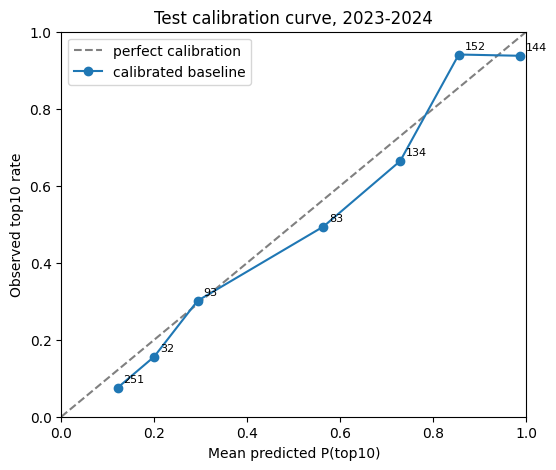

In [8]:
calibration_df = pd.DataFrame({'y': y_test, 'p': test_proba})
calibration_df['bin'] = pd.qcut(calibration_df['p'], q=10, duplicates='drop')
curve = calibration_df.groupby('bin', observed=True).agg(
    mean_pred=('p', 'mean'),
    observed_rate=('y', 'mean'),
    n=('y', 'size'),
).reset_index(drop=True)
display(curve)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
ax.plot(curve['mean_pred'], curve['observed_rate'], marker='o', label='calibrated baseline')
for _, row in curve.iterrows():
    ax.annotate(int(row['n']), (row['mean_pred'], row['observed_rate']), textcoords='offset points', xytext=(4, 4), fontsize=8)
ax.set_xlabel('Mean predicted P(top10)')
ax.set_ylabel('Observed top10 rate')
ax.set_title('Test calibration curve, 2023-2024')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

## 8. Concrete What-If Example

In [9]:
example = test[(test['season'].eq(2024)) & (test['race_name'].str.contains('Monaco', case=False, na=False)) & (test['driver_name'].eq('Leclerc'))].head(1).copy()
if len(example) == 0:
    example = test.head(1).copy()
scenario_a = example.copy()
scenario_b = example.copy()
scenario_a[['n_stops', 'strategy_type', 'compound_sequence', 'stint1_length', 'stint2_length', 'stint3_length', 'avg_pit_stop_duration_s', 'total_pit_time_s', 'first_pit_lap', 'last_pit_lap']] = [1, 'one_stop', 'M-H', 34, 44, 0, 22.5, 22.5, 34, 34]
scenario_b[['n_stops', 'strategy_type', 'compound_sequence', 'stint1_length', 'stint2_length', 'stint3_length', 'avg_pit_stop_duration_s', 'total_pit_time_s', 'first_pit_lap', 'last_pit_lap']] = [2, 'two_stop', 'M-M-H', 22, 21, 35, 22.5, 45.0, 22, 43]
scenario_probs = iso.predict(clf.predict_proba(pd.concat([scenario_a, scenario_b])[feature_cols])[:, 1])
pd.DataFrame({
    'scenario': ['one-stop M-H', 'two-stop M-M-H'],
    'driver': [example['driver_name'].iloc[0]] * 2,
    'race': [example['race_name'].iloc[0]] * 2,
    'predicted_P_top10': scenario_probs,
    'delta_vs_first': scenario_probs - scenario_probs[0],
})

,scenario,driver,race,predicted_P_top10,delta_vs_first
0,one-stop M-H,Leclerc,Monaco Grand Prix,0.999,0.0
1,two-stop M-M-H,Leclerc,Monaco Grand Prix,0.999,0.0
